In [1]:
!pip install keras-tuner -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 5.9 MB/s eta 0:00:00


In [ ]:
import json
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from scipy.stats import spearmanr
import keras_tuner as kt

# Load Data
with open('/content/train.json') as f:
    raw = json.load(f)

def build_text(item):
    parts = [
        item.get('precontext', ''),
        item.get('sentence', ''),
        item.get('ending', ''),
        item.get('judged_meaning', '')
    ]
    return ' '.join([p for p in parts if p])

items  = list(raw.values())
texts  = [build_text(i) for i in items]
labels = [i['average'] for i in items]
stdevs = [i['stdev'] for i in items]

# Tokenize
MAX_WORDS = 10000
MAX_LEN   = 200

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(texts)

X = pad_sequences(tokenizer.texts_to_sequences(texts), maxlen=MAX_LEN, padding='post')
y = np.array(labels, dtype=np.float32)
s = np.array(stdevs, dtype=np.float32)

X_train, X_val, y_train, y_val, s_train, s_val = train_test_split(
    X, y, s, test_size=0.15, random_state=42
)

# Model Builder 
def build_model(hp):
    embed_dim   = hp.Choice('embed_dim',   [64, 128, 256])
    rnn_units   = hp.Choice('rnn_units',   [64, 128, 256])
    num_layers  = hp.Int('num_layers',     1, 3)
    dropout     = hp.Float('dropout',      0.2, 0.5, step=0.1)
    l2_reg      = hp.Choice('l2_reg',      [1e-4, 1e-3, 1e-2])
    dense_units = hp.Choice('dense_units', [32, 64, 128])
    lr          = hp.Choice('lr',          [1e-3, 5e-4, 1e-4])

    inp = keras.Input(shape=(MAX_LEN,))
    x   = layers.Embedding(MAX_WORDS, embed_dim)(inp)

    # Stacked Bidirectional SimpleRNN
    for i in range(num_layers):
        return_seq = (i < num_layers - 1)   # all but last return sequences
        x = layers.Bidirectional(
            layers.SimpleRNN(rnn_units,
                             return_sequences=return_seq,
                             kernel_regularizer=regularizers.l2(l2_reg),
                             dropout=dropout,
                             recurrent_dropout=0.1)
        )(x)
        x = layers.BatchNormalization()(x)

    x   = layers.Dense(dense_units, activation='relu',
                       kernel_regularizer=regularizers.l2(l2_reg))(x)
    x   = layers.Dropout(dropout)(x)
    out = layers.Dense(1, activation='linear')(x)   # regression output

    model = keras.Model(inp, out)
    model.compile(
        optimizer=keras.optimizers.Adam(lr),
        loss='mse',
        metrics=['mae']
    )
    return model

# Hyperparameter Tuning
tuner = kt.RandomSearch(
    build_model,
    objective='val_mae',
    max_trials=15,
    directory='/content/tuner',
    project_name='ambistory_rnn'
)

callbacks = [
    keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.5, verbose=1)
]

tuner.search(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1
)

# Train Best Model 
best_hp    = tuner.get_best_hyperparameters(num_trials=1)[0]
best_model = tuner.get_best_models(num_models=1)[0]
best_model.summary()

print("\nBest Hyperparameters:")
for key in ['embed_dim','rnn_units','num_layers','dropout','l2_reg','dense_units','lr']:
    print(f"  {key}: {best_hp.get(key)}")

# Evaluate
def evaluate(model, X, y_true, stdevs):
    preds  = model.predict(X).flatten()
    preds  = np.clip(preds, 1, 5)
    stdevs = np.maximum(stdevs, 1.0)          # min std = 1 per task rules

    spear  = spearmanr(y_true, preds).correlation
    within = np.mean(np.abs(preds - y_true) <= stdevs)

    print(f"Spearman Correlation      : {spear:.4f}")
    print(f"Accuracy within Std Dev   : {within:.4f}")
    return preds

print("\n── Validation Results ──")
val_preds = evaluate(best_model, X_val, y_val, s_val)

# Predict on Test
with open('/content/test.json') as f:
    test_raw = json.load(f)

test_items = list(test_raw.values())
test_texts = [build_text(i) for i in test_items]
X_test     = pad_sequences(tokenizer.texts_to_sequences(test_texts), maxlen=MAX_LEN, padding='post')

test_preds = np.clip(best_model.predict(X_test).flatten(), 1, 5)

print("\n── Sample Test Predictions ──")
for i in range(min(10, len(test_preds))):
    print(f"  Sample {i+1}: {test_preds[i]:.3f}")

Trial 15 Complete [00h 00m 39s]
val_mae: 1.0558725595474243

Best val_mae So Far: 1.0501049757003784
Total elapsed time: 00h 20m 08s


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 28 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 200, 256)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │        16,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,841,153 (10.84 MB)

 Trainable params: 2,840,129 (10.83 MB)

 Non-trainable params: 1,024 (4.00 KB)


Best Hyperparameters:
  embed_dim: 256
  rnn_units: 256
  num_layers: 1
  dropout: 0.30000000000000004
  l2_reg: 0.001
  dense_units: 32
  lr: 0.0001

── Validation Results ──
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 112ms/step
Spearman Correlation      : 0.0720
Accuracy within Std Dev   : 0.5468
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step

── Sample Test Predictions ──
  Sample 1: 3.293
  Sample 2: 3.101
  Sample 3: 3.274
  Sample 4: 3.121
  Sample 5: 3.083
  Sample 6: 3.249
  Sample 7: 3.081
  Sample 8: 3.075
  Sample 9: 3.036
  Sample 10: 3.162


11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


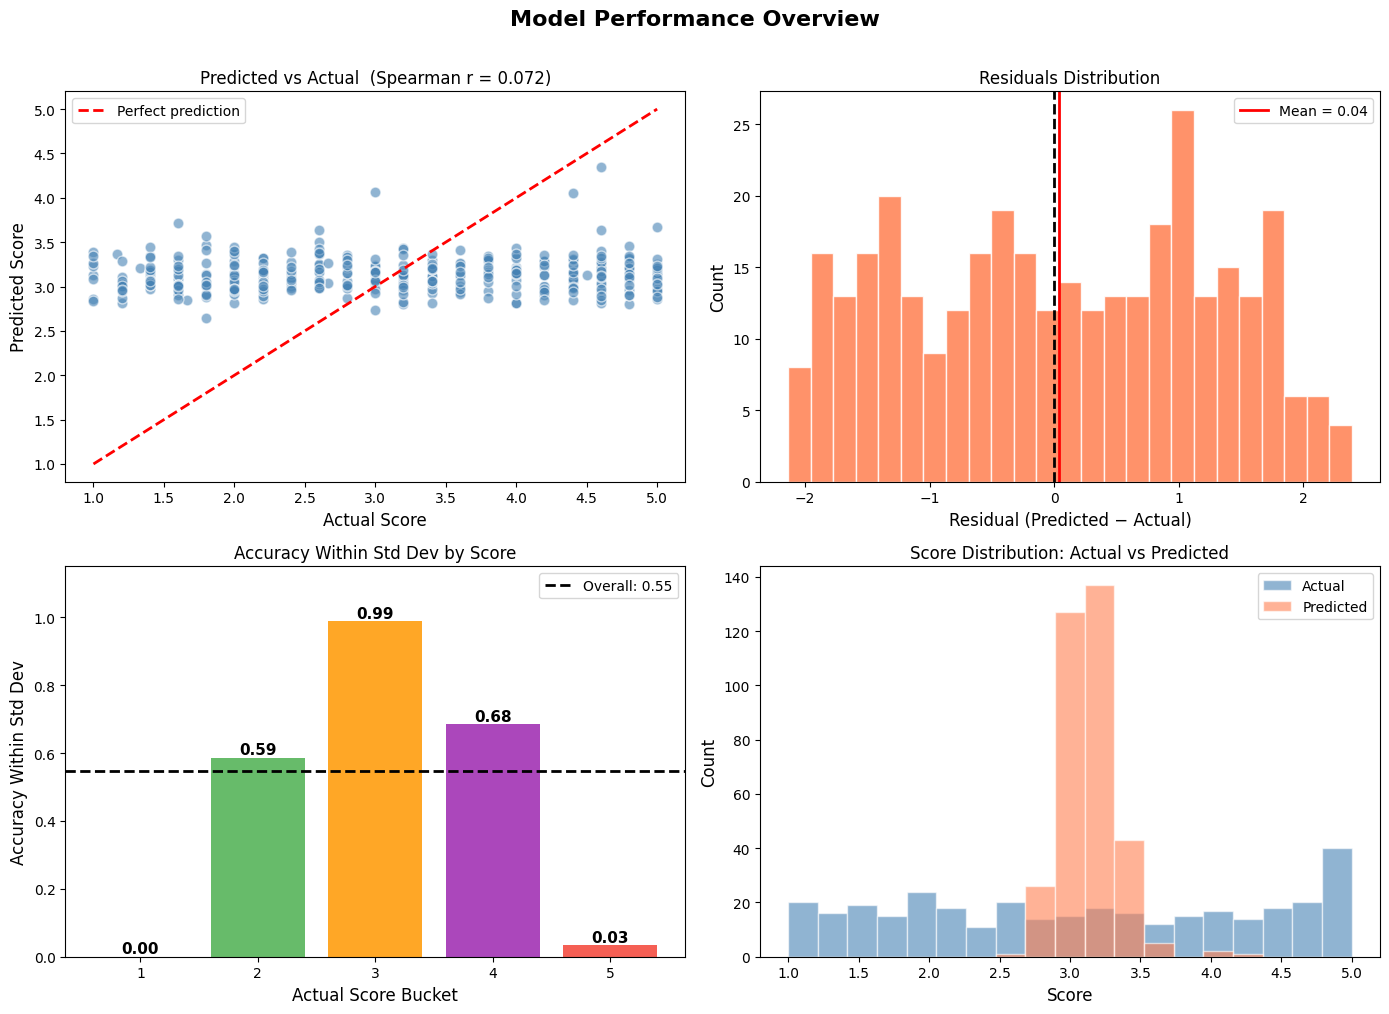

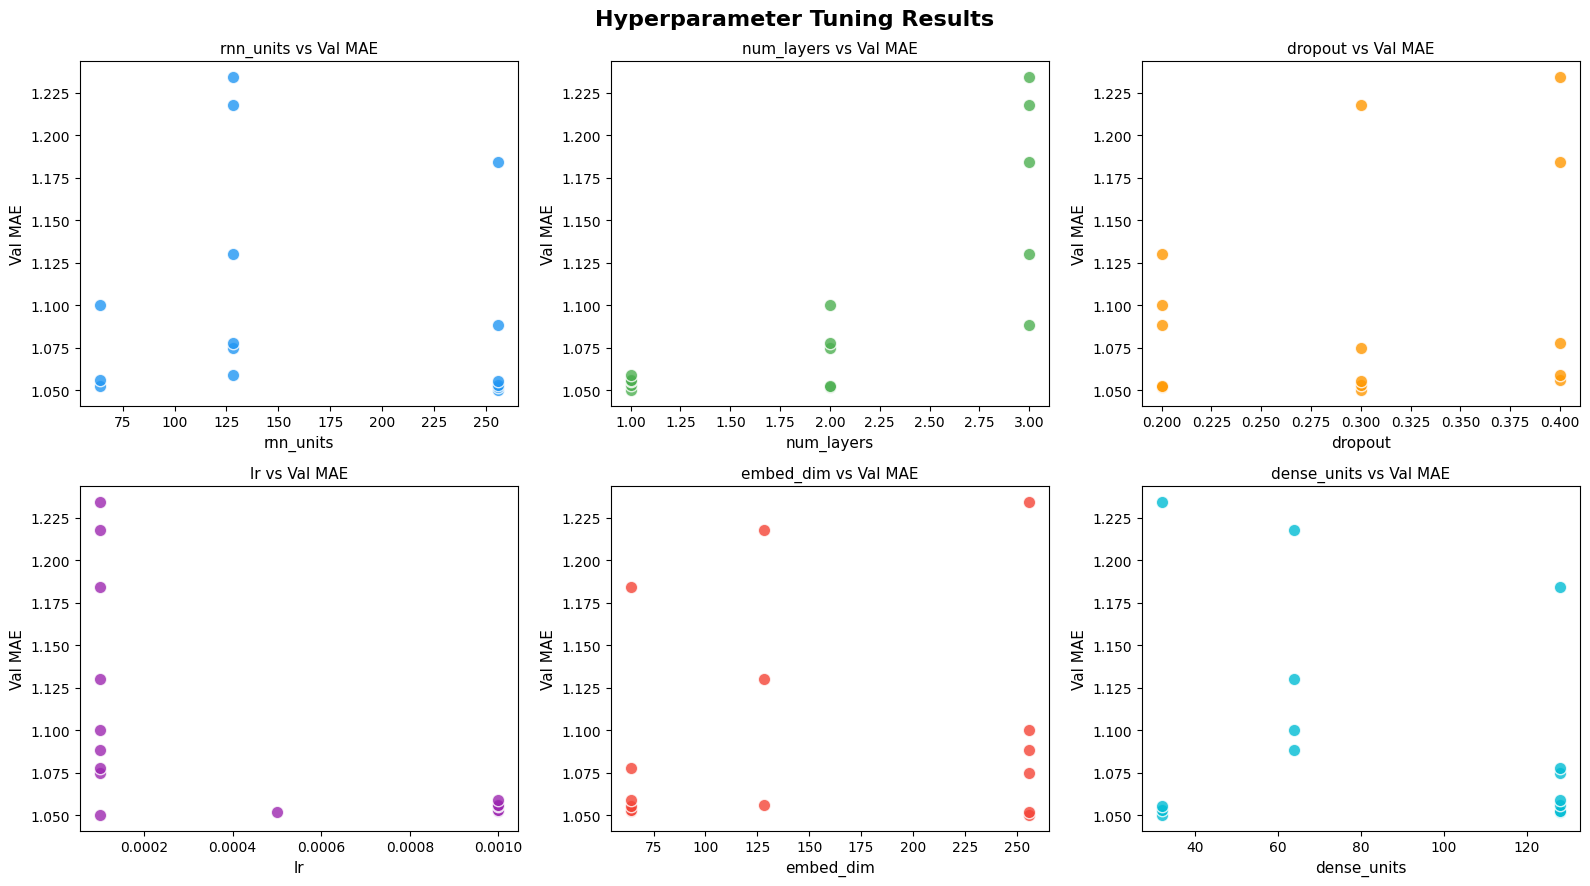

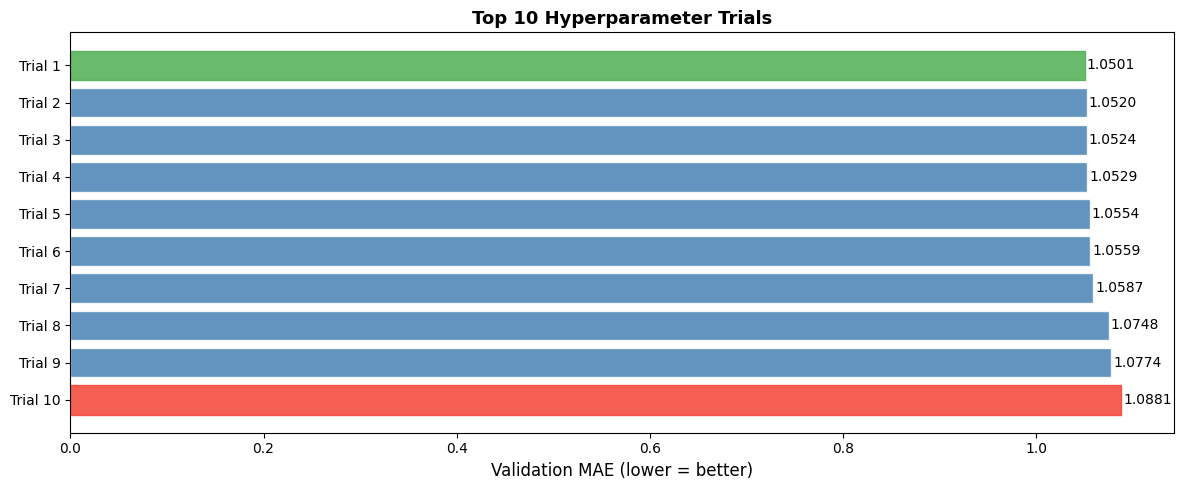

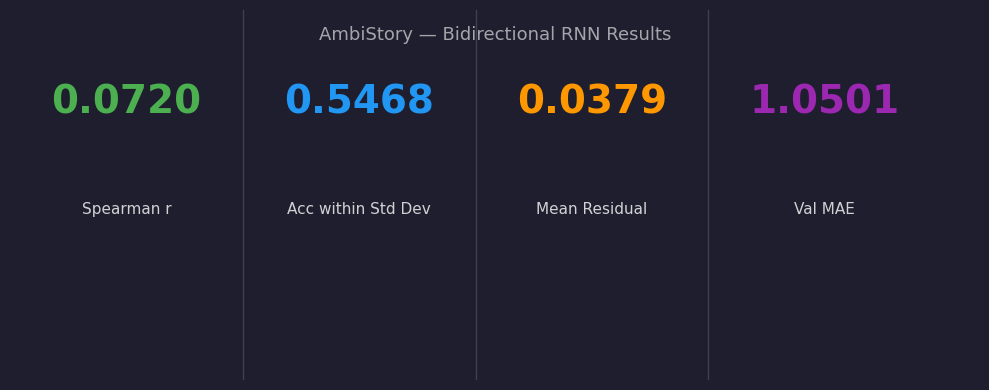


✓ Saved:
  /content/performance_overview.png
  /content/hyperparam_tuning.png
  /content/top10_trials.png
  /content/summary_card.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
from scipy.stats import spearmanr

# ── Run this AFTER your model is trained ──────────────────────────────────
# Assumes: best_model, X_val, y_val, s_val, tuner, history are available

val_preds = np.clip(best_model.predict(X_val).flatten(), 1, 5)
stdevs    = np.maximum(s_val, 1.0)
within    = np.abs(val_preds - y_val) <= stdevs
spear     = spearmanr(y_val, val_preds).correlation

# ── Get all trial results from tuner ──────────────────────────────────────
trial_data = []
for trial in tuner.oracle.trials.values():
    if trial.score is not None:
        trial_data.append({
            'val_mae'   : trial.score,
            'rnn_units' : trial.hyperparameters.values.get('rnn_units'),
            'num_layers': trial.hyperparameters.values.get('num_layers'),
            'dropout'   : trial.hyperparameters.values.get('dropout'),
            'lr'        : trial.hyperparameters.values.get('lr'),
            'embed_dim' : trial.hyperparameters.values.get('embed_dim'),
            'l2_reg'    : trial.hyperparameters.values.get('l2_reg'),
            'dense_units': trial.hyperparameters.values.get('dense_units'),
        })
trial_data = sorted(trial_data, key=lambda x: x['val_mae'])

# ═══════════════════════════════════════════════════════════════════════════
# FIGURE 1 — Model Performance Overview
# ═══════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Model Performance Overview', fontsize=16, fontweight='bold', y=1.01)

# ── 1. Predicted vs Actual ─────────────────────────────────────────────────
ax = axes[0, 0]
ax.scatter(y_val, val_preds, alpha=0.6, color='steelblue', edgecolors='white', s=60)
ax.plot([1, 5], [1, 5], 'r--', lw=2, label='Perfect prediction')
ax.set_xlabel('Actual Score', fontsize=12)
ax.set_ylabel('Predicted Score', fontsize=12)
ax.set_title(f'Predicted vs Actual  (Spearman r = {spear:.3f})', fontsize=12)
ax.legend()
ax.set_xlim(0.8, 5.2); ax.set_ylim(0.8, 5.2)

# ── 2. Residuals Distribution ─────────────────────────────────────────────
ax = axes[0, 1]
residuals = val_preds - y_val
ax.hist(residuals, bins=25, color='coral', edgecolor='white', alpha=0.85)
ax.axvline(0, color='black', linestyle='--', lw=2)
ax.axvline(residuals.mean(), color='red', linestyle='-', lw=2, label=f'Mean = {residuals.mean():.2f}')
ax.set_xlabel('Residual (Predicted − Actual)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Residuals Distribution', fontsize=12)
ax.legend()

# ── 3. Within Std Dev per Score Bucket ────────────────────────────────────
ax = axes[1, 0]
buckets = [1, 2, 3, 4, 5]
bucket_acc = []
for b in buckets:
    mask = (np.round(y_val) == b)
    bucket_acc.append(within[mask].mean() if mask.sum() > 0 else 0)

bars = ax.bar([str(b) for b in buckets], bucket_acc,
              color=['#2196F3','#4CAF50','#FF9800','#9C27B0','#F44336'], alpha=0.85)
ax.axhline(within.mean(), color='black', linestyle='--', lw=2,
           label=f'Overall: {within.mean():.2f}')
for bar, val in zip(bars, bucket_acc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.2f}', ha='center', fontsize=11, fontweight='bold')
ax.set_xlabel('Actual Score Bucket', fontsize=12)
ax.set_ylabel('Accuracy Within Std Dev', fontsize=12)
ax.set_title('Accuracy Within Std Dev by Score', fontsize=12)
ax.set_ylim(0, 1.15)
ax.legend()

# ── 4. Score Distribution: Actual vs Predicted ────────────────────────────
ax = axes[1, 1]
bins = np.linspace(1, 5, 20)
ax.hist(y_val,     bins=bins, alpha=0.6, color='steelblue', label='Actual',    edgecolor='white')
ax.hist(val_preds, bins=bins, alpha=0.6, color='coral',     label='Predicted', edgecolor='white')
ax.set_xlabel('Score', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Score Distribution: Actual vs Predicted', fontsize=12)
ax.legend()

plt.tight_layout()
plt.savefig('/content/performance_overview.png', dpi=150, bbox_inches='tight')
plt.show()

# ═══════════════════════════════════════════════════════════════════════════
# FIGURE 2 — Hyperparameter Tuning Results
# ═══════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Hyperparameter Tuning Results', fontsize=16, fontweight='bold')

params = ['rnn_units', 'num_layers', 'dropout', 'lr', 'embed_dim', 'dense_units']
colors = ['#2196F3','#4CAF50','#FF9800','#9C27B0','#F44336','#00BCD4']

for ax, param, color in zip(axes.flat, params, colors):
    vals    = [t[param] for t in trial_data if t[param] is not None]
    scores  = [t['val_mae'] for t in trial_data if t[param] is not None]
    ax.scatter(vals, scores, color=color, alpha=0.8, s=80, edgecolors='white')
    ax.set_xlabel(param, fontsize=11)
    ax.set_ylabel('Val MAE', fontsize=11)
    ax.set_title(f'{param} vs Val MAE', fontsize=11)

plt.tight_layout()
plt.savefig('/content/hyperparam_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

# ═══════════════════════════════════════════════════════════════════════════
# FIGURE 3 — Top 10 Trials Ranked
# ═══════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(12, 5))
top10   = trial_data[:10]
labels  = [f"Trial {i+1}" for i in range(len(top10))]
maes    = [t['val_mae'] for t in top10]

bars = ax.barh(labels[::-1], maes[::-1], color='steelblue', alpha=0.85, edgecolor='white')
bars[0].set_color('#F44336')   # highlight worst of top10
bars[-1].set_color('#4CAF50')  # highlight best

for bar, val in zip(bars, maes[::-1]):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10)

ax.set_xlabel('Validation MAE (lower = better)', fontsize=12)
ax.set_title('Top 10 Hyperparameter Trials', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/top10_trials.png', dpi=150, bbox_inches='tight')
plt.show()

# ═══════════════════════════════════════════════════════════════════════════
# FIGURE 4 — Summary Card (for Illustrator)
# ═══════════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(10, 4))
fig.patch.set_facecolor('#1E1E2E')
ax  = fig.add_subplot(111)
ax.set_facecolor('#1E1E2E')
ax.axis('off')

metrics = [
    ('Spearman r',           f'{spear:.4f}',          '#4CAF50'),
    ('Acc within Std Dev',   f'{within.mean():.4f}',  '#2196F3'),
    ('Mean Residual',        f'{residuals.mean():.4f}','#FF9800'),
    ('Val MAE',              f'{trial_data[0]["val_mae"]:.4f}', '#9C27B0'),
]

for i, (label, value, color) in enumerate(metrics):
    x = 0.12 + i * 0.24
    ax.text(x, 0.72, value, transform=ax.transAxes,
            fontsize=28, fontweight='bold', color=color, ha='center')
    ax.text(x, 0.45, label, transform=ax.transAxes,
            fontsize=11, color='white', ha='center', alpha=0.8)
    if i < len(metrics)-1:
        ax.axvline(x + 0.12, color='white', alpha=0.15, lw=1)

ax.text(0.5, 0.92, 'AmbiStory — Bidirectional RNN Results',
        transform=ax.transAxes, fontsize=13, color='white',
        ha='center', alpha=0.6)

plt.tight_layout()
plt.savefig('/content/summary_card.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

print("\n✓ Saved:")
print("  /content/performance_overview.png")
print("  /content/hyperparam_tuning.png")
print("  /content/top10_trials.png")
print("  /content/summary_card.png")